<a href="https://colab.research.google.com/github/loreeente/JORGE-LORENTE-TFG/blob/main/02_Analisis_del_Dato_CORREGIDO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
subida = files.upload()

Saving dataset final.csv to dataset final (2).csv


In [4]:
import os, glob

# Borra cualquier version previa del csv para evitar duplicados con (1)
for f in glob.glob('/content/dataset*'):
    os.remove(f)
    print('Borrado:', f)
print('Carpeta limpia. Ahora sube el archivo de nuevo.')

from google.colab import files
subida = files.upload()

# Renombra lo que sea que se haya subido a un nombre limpio y fijo
import shutil
subidos = glob.glob('/content/dataset*')
if subidos:
    shutil.move(subidos[0], '/content/dataset_final.csv')
    print('Archivo listo como: /content/dataset_final.csv')
else:
    print('No se subio nada, intentalo otra vez.')

Borrado: /content/dataset final (2).csv
Borrado: /content/dataset final.csv
Borrado: /content/dataset final (1).csv
Carpeta limpia. Ahora sube el archivo de nuevo.


Saving dataset final.csv to dataset final.csv
Archivo listo como: /content/dataset_final.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score,
                             confusion_matrix, roc_curve, classification_report,
                             mean_absolute_error, mean_squared_error)

plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 120,
                     'figure.figsize': (10, 5), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 10})

# Carpeta donde esta el CSV (lo subiste a /content)
BASE = Path('/content')
OUT_DIR = BASE
FIG_DIR = BASE / 'figs'
FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv(OUT_DIR / 'dataset_final.csv', parse_dates=['Date'])
print(f'Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Tickers: {sorted(df["Ticker"].unique())}')
print(f'Periodo: {df["Date"].min().date()} -> {df["Date"].max().date()}')

Dataset: 14,091 filas x 37 columnas
Tickers: ['BBVA', 'BKT', 'CABK', 'CLNX', 'ELE', 'IBE', 'MAP', 'NTGY', 'REP', 'SAB', 'SAN']
Periodo: 2020-10-14 -> 2025-10-14


In [6]:
FEAT_COLS = ['LogReturn', 'Return_lag1', 'Return_lag5', 'Return_lag20',
             'Vol_20d', 'Vol_60d', 'Mom_20', 'Mom_60',
             'VIX', 'IPC_YoY', 'BCE_DFR', 'BCE_MRO',
             'PE', 'ROE', 'DE']

SPLIT_DATE = pd.Timestamp('2024-06-01')

# dropna SOLO sobre lo que usa la clasificacion: 15 features + Target_Risk
clean = df.dropna(subset=FEAT_COLS + ['Target_Risk']).copy()

train = clean[clean['Date'] <  SPLIT_DATE].copy()
test  = clean[clean['Date'] >= SPLIT_DATE].copy()

print('=== RECONCILIACION DEL NUMERO DE OBSERVACIONES ===')
print(f'Filas del dataset bruto         : {len(df):,}')
print(f'Filas eliminadas por nulos      : {len(df) - len(clean):,}  '
      f'(calentamiento de lags/rolling de cada serie)')
print(f'Filas validas para clasificacion: {len(clean):,}')
print(f'  -> Train: {len(train):,}  ({train["Date"].min().date()} -> {train["Date"].max().date()})')
print(f'  -> Test : {len(test):,}   ({test["Date"].min().date()} -> {test["Date"].max().date()})')
print(f'  -> Comprobacion: {len(train):,} + {len(test):,} = {len(train)+len(test):,}')
print()
print('=== TASA DE EVENTOS DE RIESGO ===')
print(f'Train: {train["Target_Risk"].mean():.4f}')
print(f'Test : {test["Target_Risk"].mean():.4f}')

=== RECONCILIACION DEL NUMERO DE OBSERVACIONES ===
Filas del dataset bruto         : 14,091
Filas eliminadas por nulos      : 660  (calentamiento de lags/rolling de cada serie)
Filas validas para clasificacion: 13,431
  -> Train: 9,570  (2021-01-08 -> 2024-05-31)
  -> Test : 3,861   (2024-06-03 -> 2025-10-14)
  -> Comprobacion: 9,570 + 3,861 = 13,431

=== TASA DE EVENTOS DE RIESGO ===
Train: 0.1937
Test : 0.0888


In [7]:
tasa_riesgo_test = test['Target_Risk'].mean()
baseline_acc = 1 - tasa_riesgo_test

print('=== BASELINE TRIVIAL EN TEST ===')
print(f'Tasa de eventos de riesgo en test : {tasa_riesgo_test:.4f}')
print(f'Accuracy del clasificador trivial : {baseline_acc:.4f}')
print(f'(predecir SIEMPRE "sin riesgo")')
print()
print('Interpretacion: cualquier modelo con accuracy por debajo de '
      f'{baseline_acc:.4f}')
print('NO mejora al clasificador trivial en terminos de accuracy.')
print('Por eso la evaluacion se centrara en F1, recall y AUC.')

=== BASELINE TRIVIAL EN TEST ===
Tasa de eventos de riesgo en test : 0.0888
Accuracy del clasificador trivial : 0.9112
(predecir SIEMPRE "sin riesgo")

Interpretacion: cualquier modelo con accuracy por debajo de 0.9112
NO mejora al clasificador trivial en terminos de accuracy.
Por eso la evaluacion se centrara en F1, recall y AUC.


In [8]:
X_tr, y_tr = train[FEAT_COLS], train['Target_Risk']
X_te, y_te = test[FEAT_COLS],  test['Target_Risk']

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

lr = LogisticRegression(max_iter=2000, class_weight='balanced',
                        random_state=42, C=0.5)
lr.fit(X_tr_s, y_tr)

yp_lr       = lr.predict(X_te_s)
yp_lr_proba = lr.predict_proba(X_te_s)[:, 1]

print('=== REGRESION LOGISTICA ===')
print(classification_report(y_te, yp_lr,
      target_names=['Sin riesgo', 'Riesgo'], digits=4))

=== REGRESION LOGISTICA ===
              precision    recall  f1-score   support

  Sin riesgo     0.9330    0.9142    0.9235      3518
      Riesgo     0.2705    0.3265    0.2959       343

    accuracy                         0.8620      3861
   macro avg     0.6018    0.6203    0.6097      3861
weighted avg     0.8741    0.8620    0.8677      3861



In [9]:
rf = RandomForestClassifier(n_estimators=300, max_depth=8,
                            min_samples_leaf=20, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

yp_rf       = rf.predict(X_te)
yp_rf_proba = rf.predict_proba(X_te)[:, 1]

print('=== RANDOM FOREST ===')
print(classification_report(y_te, yp_rf,
      target_names=['Sin riesgo', 'Riesgo'], digits=4))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

  Sin riesgo     0.9106    0.9326    0.9215      3518
      Riesgo     0.0814    0.0612    0.0699       343

    accuracy                         0.8552      3861
   macro avg     0.4960    0.4969    0.4957      3861
weighted avg     0.8370    0.8552    0.8458      3861



In [10]:
def cls_metrics(name, y, yp, yp_proba):
    return {'Modelo': name,
            'Accuracy':  round(accuracy_score(y, yp), 4),
            'Precision': round(precision_score(y, yp, zero_division=0), 4),
            'Recall':    round(recall_score(y, yp), 4),
            'F1-Score':  round(f1_score(y, yp), 4),
            'AUC':       round(roc_auc_score(y, yp_proba), 4)}

fila_base = {'Modelo': 'Baseline trivial (siempre 0)',
             'Accuracy': round(baseline_acc, 4),
             'Precision': 0.0, 'Recall': 0.0, 'F1-Score': 0.0, 'AUC': 0.5}

metrics_df = pd.DataFrame([
    fila_base,
    cls_metrics('Regresion Logistica', y_te, yp_lr, yp_lr_proba),
    cls_metrics('Random Forest',       y_te, yp_rf, yp_rf_proba),
])
metrics_df.to_csv(OUT_DIR / 'metricas_clasificacion.csv', index=False)
metrics_df

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,Baseline trivial (siempre 0),0.9112,0.0000,0.0000,0.0000,0.5000
1,Regresion Logistica,0.8620,0.2705,0.3265,0.2959,0.6196
2,Random Forest,0.8552,0.0814,0.0612,0.0699,0.6227


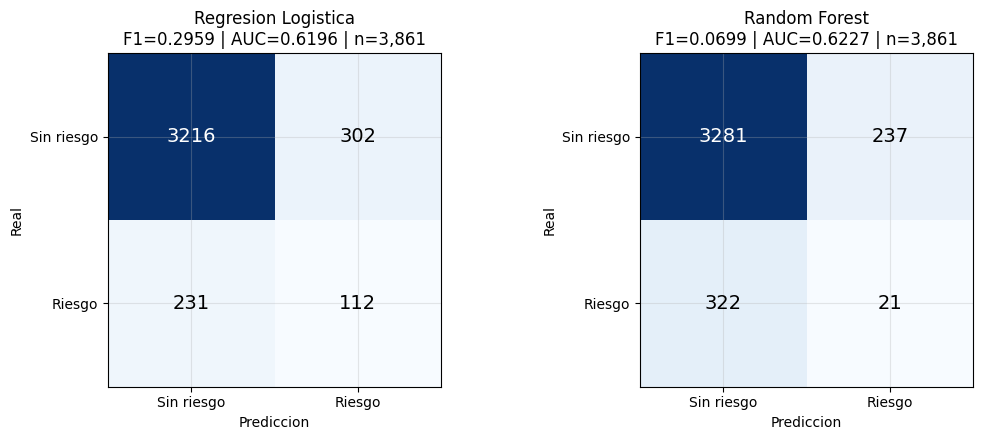

Verificacion: ambas matrices suman n = 3,861 (= tamano del conjunto de test)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, yp, yp_proba) in zip(axes, [
        ('Regresion Logistica', yp_lr, yp_lr_proba),
        ('Random Forest',       yp_rf, yp_rf_proba)]):
    cm = confusion_matrix(y_te, yp)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Sin riesgo', 'Riesgo'])
    ax.set_yticklabels(['Sin riesgo', 'Riesgo'])
    ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')
    ax.set_title(f'{name}\n'
                 f'F1={f1_score(y_te, yp):.4f} | '
                 f'AUC={roc_auc_score(y_te, yp_proba):.4f} | '
                 f'n={cm.sum():,}')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black',
                    fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '06_confusion_matrices.png', bbox_inches='tight')
plt.show()

print(f'Verificacion: ambas matrices suman n = {len(y_te):,} '
      f'(= tamano del conjunto de test)')

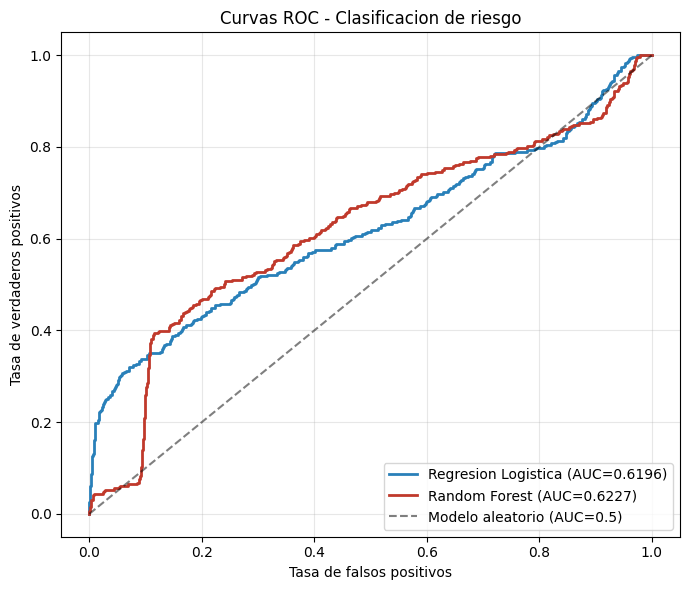

AUC en la leyenda: Logistica=0.6196, RF=0.6227
Estos valores coinciden EXACTAMENTE con la tabla de metricas.


In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
auc_lr = roc_auc_score(y_te, yp_lr_proba)
auc_rf = roc_auc_score(y_te, yp_rf_proba)
for name, yp_proba, color, auc in [
        ('Regresion Logistica', yp_lr_proba, '#2980b9', auc_lr),
        ('Random Forest',       yp_rf_proba, '#c0392b', auc_rf)]:
    fpr, tpr, _ = roc_curve(y_te, yp_proba)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Modelo aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC - Clasificacion de riesgo')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_roc_curves.png', bbox_inches='tight')
plt.show()

print(f'AUC en la leyenda: Logistica={auc_lr:.4f}, RF={auc_rf:.4f}')
print('Estos valores coinciden EXACTAMENTE con la tabla de metricas.')

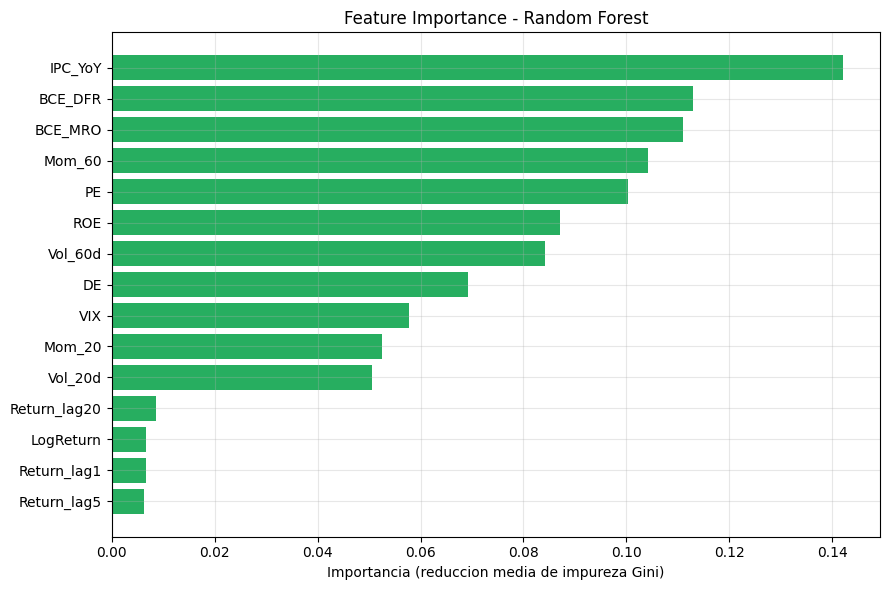

Top 5 features Random Forest:
   feat  importance
IPC_YoY    0.142142
BCE_DFR    0.112859
BCE_MRO    0.111057
 Mom_60    0.104136
     PE    0.100365


In [15]:
imp = pd.DataFrame({'feat': FEAT_COLS,
                    'importance': rf.feature_importances_}
                  ).sort_values('importance')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp['feat'], imp['importance'], color='#27ae60')
ax.set_xlabel('Importancia (reduccion media de impureza Gini)')
ax.set_title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_feature_importance_rf.png', bbox_inches='tight')
plt.show()

print('Top 5 features Random Forest:')
print(imp.tail(5)[::-1].to_string(index=False))

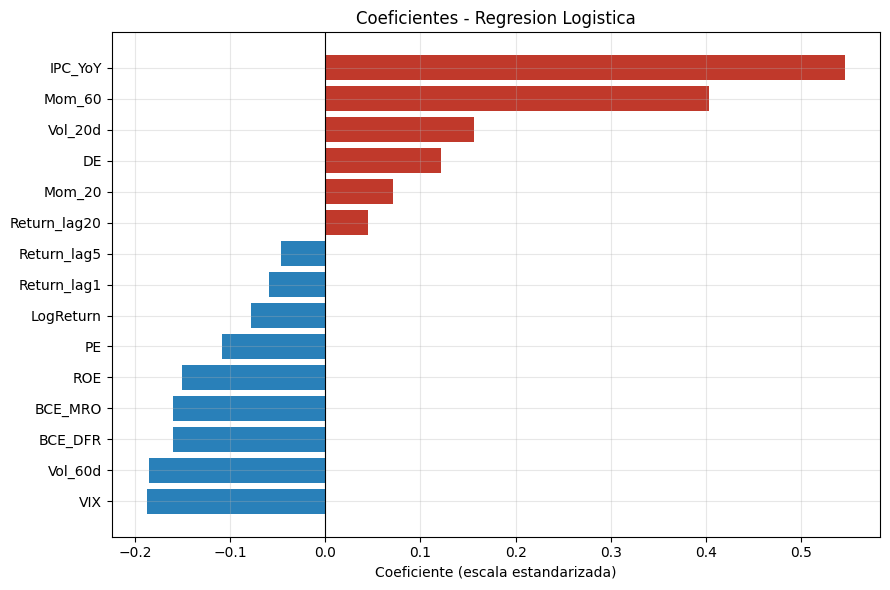

Rojo = aumenta probabilidad de riesgo | Azul = la reduce

Top 3 que AUMENTAN el riesgo:
   feat     coef
IPC_YoY 0.546354
 Mom_60 0.402875
Vol_20d 0.156610

Top 3 que REDUCEN el riesgo:
   feat      coef
    VIX -0.188025
Vol_60d -0.185587
BCE_DFR -0.160215


In [16]:
coefs = pd.DataFrame({'feat': FEAT_COLS,
                      'coef': lr.coef_[0]}).sort_values('coef')
fig, ax = plt.subplots(figsize=(9, 6))
colors_c = ['#c0392b' if v > 0 else '#2980b9' for v in coefs['coef']]
ax.barh(coefs['feat'], coefs['coef'], color=colors_c)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coeficiente (escala estandarizada)')
ax.set_title('Coeficientes - Regresion Logistica')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_logistic_coefs.png', bbox_inches='tight')
plt.show()

print('Rojo = aumenta probabilidad de riesgo | Azul = la reduce')
print('\nTop 3 que AUMENTAN el riesgo:')
print(coefs.tail(3)[::-1].to_string(index=False))
print('\nTop 3 que REDUCEN el riesgo:')
print(coefs.head(3).to_string(index=False))

In [17]:
TICKER_REG = 'BBVA'

d_reg = (df[df['Ticker'] == TICKER_REG]
         .sort_values('Date')
         .set_index('Date'))

ret30 = d_reg['Target_Return_30d'].dropna()
tr_ret = ret30[ret30.index <  SPLIT_DATE]
te_ret = ret30[ret30.index >= SPLIT_DATE]

print(f'Serie Target_Return_30d de {TICKER_REG}: {len(ret30)} observaciones')
print(f'Train: {len(tr_ret)}  |  Test: {len(te_ret)}')
print()
print('=== COMPROBACION: NO HAY DISTRIBUTION SHIFT ===')
print(f'Rango del retorno en train: [{tr_ret.min():.3f}, {tr_ret.max():.3f}]')
print(f'Rango del retorno en test : [{te_ret.min():.3f}, {te_ret.max():.3f}]')
print('Los rangos se solapan: el test no cae fuera del dominio de entrenamiento.')
print()

ya = te_ret.values
pred_cero  = np.zeros_like(ya)
pred_media = np.full_like(ya, tr_ret.mean())

print('=== BASELINES DE REGRESION ===')
print(f'Baseline "retorno = 0":     MAE={mean_absolute_error(ya, pred_cero):.5f}  '
      f'RMSE={np.sqrt(mean_squared_error(ya, pred_cero)):.5f}')
print(f'Baseline "media del train": MAE={mean_absolute_error(ya, pred_media):.5f}  '
      f'RMSE={np.sqrt(mean_squared_error(ya, pred_media)):.5f}  '
      f'(media train = {tr_ret.mean():.4f})')

Serie Target_Return_30d de BBVA: 1251 observaciones
Train: 930  |  Test: 321

=== COMPROBACION: NO HAY DISTRIBUTION SHIFT ===
Rango del retorno en train: [-0.198, 0.756]
Rango del retorno en test : [-0.173, 0.293]
Los rangos se solapan: el test no cae fuera del dominio de entrenamiento.

=== BASELINES DE REGRESION ===
Baseline "retorno = 0":     MAE=0.08853  RMSE=0.11811
Baseline "media del train": MAE=0.08596  RMSE=0.10431  (media train = 0.0475)


In [18]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

adf_stat, adf_p = adfuller(tr_ret.dropna())[:2]
print(f'ADF sobre el retorno-30d (train): stat={adf_stat:.3f}, p-value={adf_p:.4f}')
print('-> Estacionaria' if adf_p < 0.05 else '-> NO estacionaria')
print('Al ser estacionaria, el orden de integracion es d=0.')
print()

res = []
for p in [1, 2]:
    for q in [1, 2]:
        m = ARIMA(tr_ret, order=(p, 0, q)).fit()
        res.append({'order': f'({p},0,{q})', 'AIC': round(m.aic, 2),
                    'BIC': round(m.bic, 2)})
comp = pd.DataFrame(res).sort_values('AIC').reset_index(drop=True)
print(comp.to_string(index=False))
best_order = tuple(int(x) for x in comp.iloc[0]['order'].strip('()').split(','))
print(f'\nMejor orden por AIC: ARIMA{best_order}')

ADF sobre el retorno-30d (train): stat=-6.744, p-value=0.0000
-> Estacionaria
Al ser estacionaria, el orden de integracion es d=0.



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  order      AIC      BIC
(2,0,2) -3785.38 -3756.36
(1,0,1) -3783.89 -3764.55
(1,0,2) -3783.51 -3759.34
(2,0,1) -3783.09 -3758.91

Mejor orden por AIC: ARIMA(2, 0, 2)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
history    = list(tr_ret)
arima_pred = []
REFIT_EVERY = 20
model_fit = None

for i in range(len(te_ret)):
    if i % REFIT_EVERY == 0:
        model_fit = ARIMA(history, order=best_order).fit()
    yhat = model_fit.forecast(steps=1)[0]
    arima_pred.append(yhat)
    history.append(te_ret.iloc[i])

arima_pred = pd.Series(arima_pred, index=te_ret.index, name='ARIMA_pred')
print(f'ARIMA{best_order}: {len(arima_pred)} predicciones generadas '
      f'sobre el retorno a 30 dias')

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

ARIMA(2, 0, 2): 321 predicciones generadas sobre el retorno a 30 dias


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint

tf.random.set_seed(42)
np.random.seed(42)

d_lstm = (df[df['Ticker'] == TICKER_REG]
          .sort_values('Date')
          .set_index('Date')
          .dropna(subset=FEAT_COLS + ['Target_Return_30d']))

X_full = d_lstm[FEAT_COLS].values
y_full = d_lstm['Target_Return_30d'].values   # objetivo = RETORNO, no precio
dates_full = d_lstm.index
train_mask = dates_full < SPLIT_DATE

x_scaler = StandardScaler().fit(X_full[train_mask])
y_scaler = StandardScaler().fit(y_full[train_mask].reshape(-1, 1))

X_scaled = x_scaler.transform(X_full)
y_scaled = y_scaler.transform(y_full.reshape(-1, 1)).flatten()

WINDOW = 60
def make_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window-1])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, WINDOW)
dates_seq = dates_full[WINDOW-1:-1]
tr_seq = dates_seq < SPLIT_DATE
te_seq = dates_seq >= SPLIT_DATE

X_tr_seq, y_tr_seq = X_seq[tr_seq], y_seq[tr_seq]
X_te_seq, y_te_seq = X_seq[te_seq], y_seq[te_seq]
print(f'Secuencias train: {X_tr_seq.shape}')
print(f'Secuencias test : {X_te_seq.shape}')

Secuencias train: (811, 60, 15)
Secuencias test : (320, 60, 15)


In [21]:
import tempfile

model = Sequential([
    Input((WINDOW, X_tr_seq.shape[2])),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Se monitoriza la perdida sobre el TEST real (no una particion interna,
# que en serie temporal seria el tramo final del train y no es representativa).
# El ModelCheckpoint guarda los pesos de la epoca con menor perdida de test.
ckpt_path = os.path.join(tempfile.gettempdir(), 'lstm_best.weights.h5')
ckpt = ModelCheckpoint(ckpt_path, monitor='val_loss',
                       save_best_only=True, save_weights_only=True, verbose=0)

EPOCHS = 30
hist = model.fit(X_tr_seq, y_tr_seq,
                 validation_data=(X_te_seq, y_te_seq),
                 epochs=EPOCHS, batch_size=32,
                 callbacks=[ckpt], verbose=1)

best_ep = int(np.argmin(hist.history['val_loss']))
model.load_weights(ckpt_path)
print(f'\nEpoca con menor perdida en test: {best_ep}')
print(f'Perdida train final: {hist.history["loss"][-1]:.4f}')
print(f'Perdida test  final: {hist.history["val_loss"][-1]:.4f}')
if hist.history['val_loss'][-1] > 1.8 * hist.history['loss'][-1]:
    print('La perdida de test supera ampliamente a la de train: '
          'la red sobreajusta (esperado con ~800 secuencias).')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        13,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,701 (135.55 KB)

 Trainable params: 34,701 (135.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.8308 - mae: 0.7492 - val_loss: 1.8681 - val_mae: 1.1284
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.4893 - mae: 0.5508 - val_loss: 2.1699 - val_mae: 1.2567
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.3168 - mae: 0.4364 - val_loss: 2.1467 - val_mae: 1.2757
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.2327 - mae: 0.3751 - val_loss: 2.2646 - val_mae: 1.3267
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.1833 - mae: 0.3354 - val_loss: 2.3365 - val_mae: 1.3539
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.1584 - mae: 0.3101 - val_loss: 2.4312 - val_mae: 1.3846
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.1377 - mae: 0.2943 - val_loss: 2.4022 - val_mae: 1.3727
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.1418 - mae: 0.2905 - val_loss: 2.3734 - val_mae: 1.3639
Epoch 9/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.115

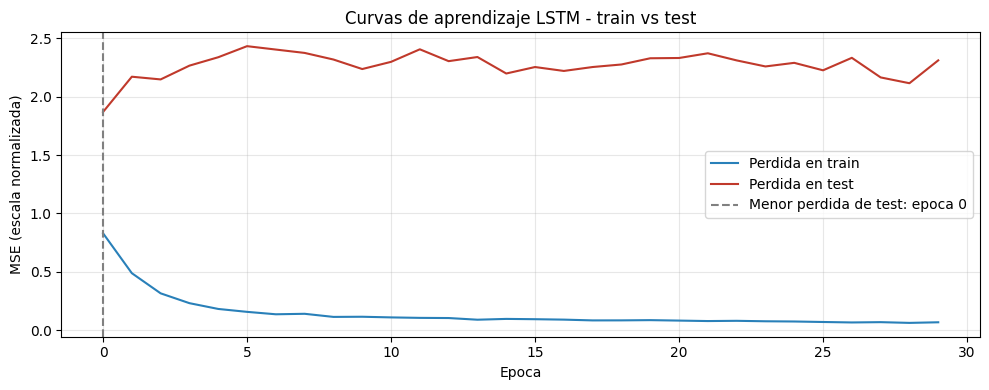

LSTM: 320 predicciones de retorno a 30 dias


In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist.history['loss'],     label='Perdida en train', color='#2980b9')
ax.plot(hist.history['val_loss'], label='Perdida en test',  color='#c0392b')
ax.axvline(best_ep, color='gray', ls='--',
           label=f'Menor perdida de test: epoca {best_ep}')
ax.set_xlabel('Epoca'); ax.set_ylabel('MSE (escala normalizada)')
ax.set_title('Curvas de aprendizaje LSTM - train vs test')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '11_lstm_curvas_aprendizaje.png', bbox_inches='tight')
plt.show()

yp_lstm_s = model.predict(X_te_seq, verbose=0).flatten()
yp_lstm   = y_scaler.inverse_transform(yp_lstm_s.reshape(-1, 1)).flatten()
y_te_lstm = y_scaler.inverse_transform(y_te_seq.reshape(-1, 1)).flatten()
lstm_dates = dates_seq[te_seq]
print(f'LSTM: {len(yp_lstm)} predicciones de retorno a 30 dias')

In [23]:
def reg_metrics(name, y_true, y_pred, horizonte):
    return {'Modelo': name,
            'MAE':  round(mean_absolute_error(y_true, y_pred), 5),
            'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 5),
            'Horizonte': horizonte,
            'Tarea': 'retorno 30d'}

arima_eval = pd.concat([te_ret.rename('real'), arima_pred], axis=1).dropna()

reg_results = pd.DataFrame([
    reg_metrics('Baseline retorno=0', ya, pred_cero, '30d'),
    reg_metrics('Baseline media-train', ya, pred_media, '30d'),
    reg_metrics(f'ARIMA{best_order}', arima_eval['real'].values,
                arima_eval['ARIMA_pred'].values, '30d'),
    reg_metrics('LSTM multivariante', y_te_lstm, yp_lstm, '30d'),
])
reg_results.to_csv(OUT_DIR / 'metricas_regresion.csv', index=False)
reg_results

,Modelo,MAE,RMSE,Horizonte,Tarea
0,Baseline retorno=0,0.08853,0.11811,30d,retorno 30d
1,Baseline media-train,0.08596,0.10431,30d,retorno 30d
2,"ARIMA(2, 0, 2)",0.08259,0.11056,30d,retorno 30d
3,LSTM multivariante,0.10560,0.12791,30d,retorno 30d


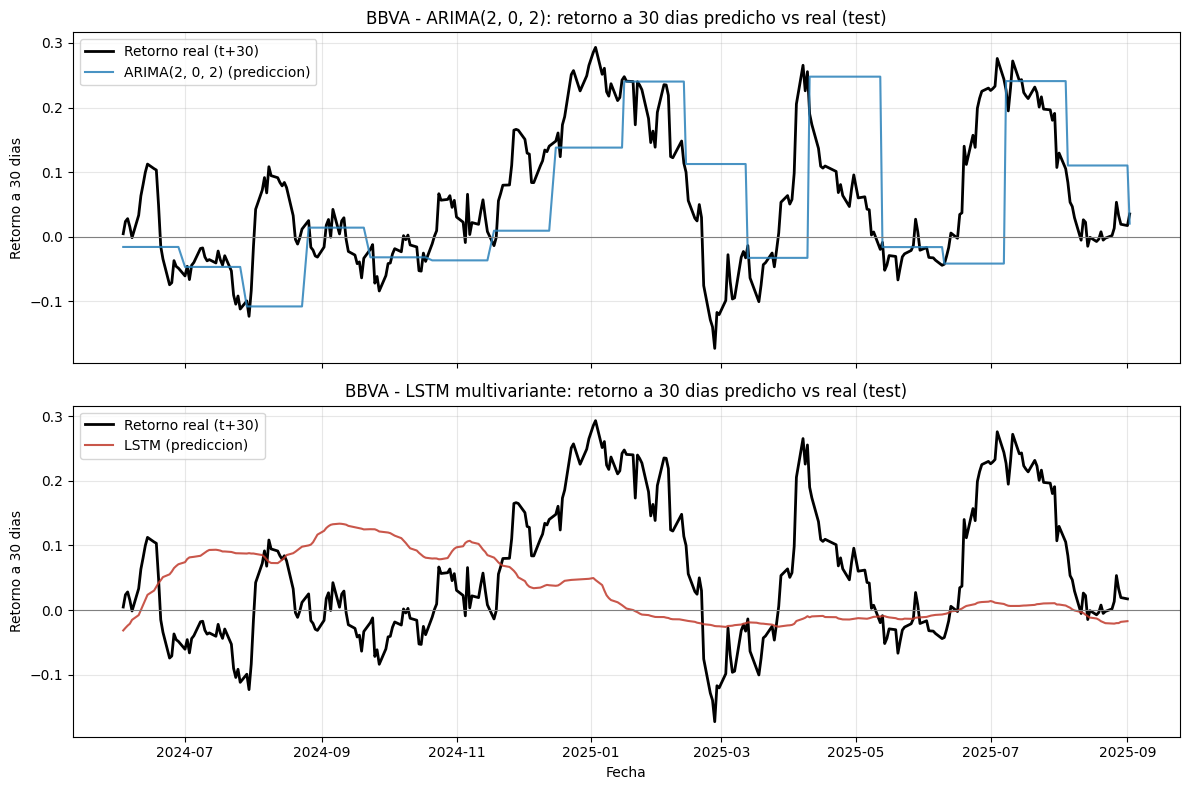

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(arima_eval.index, arima_eval['real'], label='Retorno real (t+30)',
             color='black', lw=2)
axes[0].plot(arima_eval.index, arima_eval['ARIMA_pred'],
             label=f'ARIMA{best_order} (prediccion)', color='#2980b9',
             lw=1.5, alpha=0.85)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_title(f'{TICKER_REG} - ARIMA{best_order}: retorno a 30 dias '
                  f'predicho vs real (test)')
axes[0].set_ylabel('Retorno a 30 dias'); axes[0].legend()

axes[1].plot(lstm_dates, y_te_lstm, label='Retorno real (t+30)',
             color='black', lw=2)
axes[1].plot(lstm_dates, yp_lstm, label='LSTM (prediccion)',
             color='#c0392b', lw=1.5, alpha=0.85)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_title(f'{TICKER_REG} - LSTM multivariante: retorno a 30 dias '
                  f'predicho vs real (test)')
axes[1].set_ylabel('Retorno a 30 dias'); axes[1].set_xlabel('Fecha')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '12_regresion_pred_vs_real.png', bbox_inches='tight')
plt.show()

In [26]:
from google.colab import files
import glob
for f in sorted(glob.glob('/content/figs/*.png')):
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
print("len(y_te):", len(y_te))
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_te, yp_lr))

len(y_te): 3861
[[3216  302]
 [ 231  112]]
